In [36]:
metadata = pd.read_parquet("/n/groups/patel/adithya/Validation_Metadata_Final_with_broad_types_final.parquet")

In [4]:
metadata.columns

Index(['TAG', 'sample', 'diagnosis', 'ID', 'CONDITION', 'AGE', 'SEX', 'PMD',
       'HIST DIAGNOSIS', 'DIAG 1', 'DIAG 2', 'DIAG 3',
       'AGE-RELATED PLAQUE SCORE', 'Braak tangle stage', 'APOE',
       'predicted_cell_type', 'Lau_cell_types', 'pmi', 'educ', 'cts_mmse30_lv',
       'age_death', 'apoe_genotype', 'alzheimers_or_control', 'msex',
       'pmi_bin', 'predicted_subcluster', 'broad.cell.type'],
      dtype='object')

In [2]:
import pandas as pd
metadata = pd.read_parquet("/n/groups/patel/adithya/Validation_Metadata_Final.parquet")

metadata.shape

(172514, 26)

Processing: Ast

Feature importance for APOE across splits:
Split 1: 1
Split 2: 0
Split 3: 4
Split 4: 6
Split 5: 8


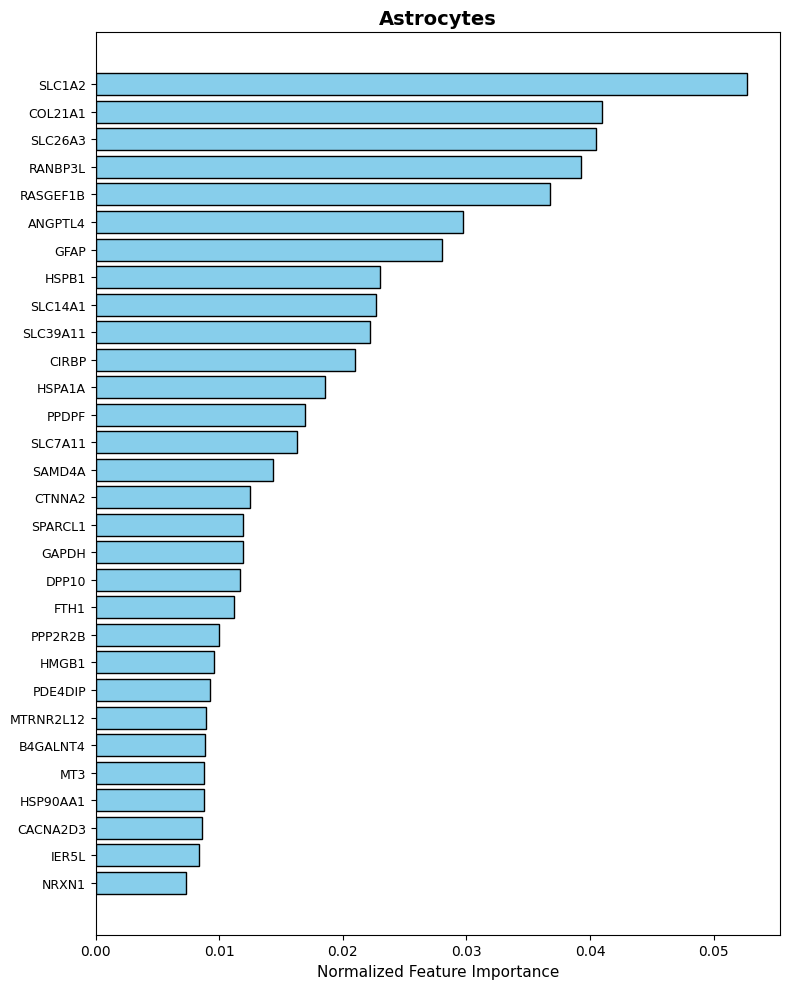

Saved plot for: Astrocytes
Processing: Mic

Feature importance for APOE across splits:
Split 1: 0
Split 2: 1
Split 3: 2
Split 4: 2
Split 5: 0


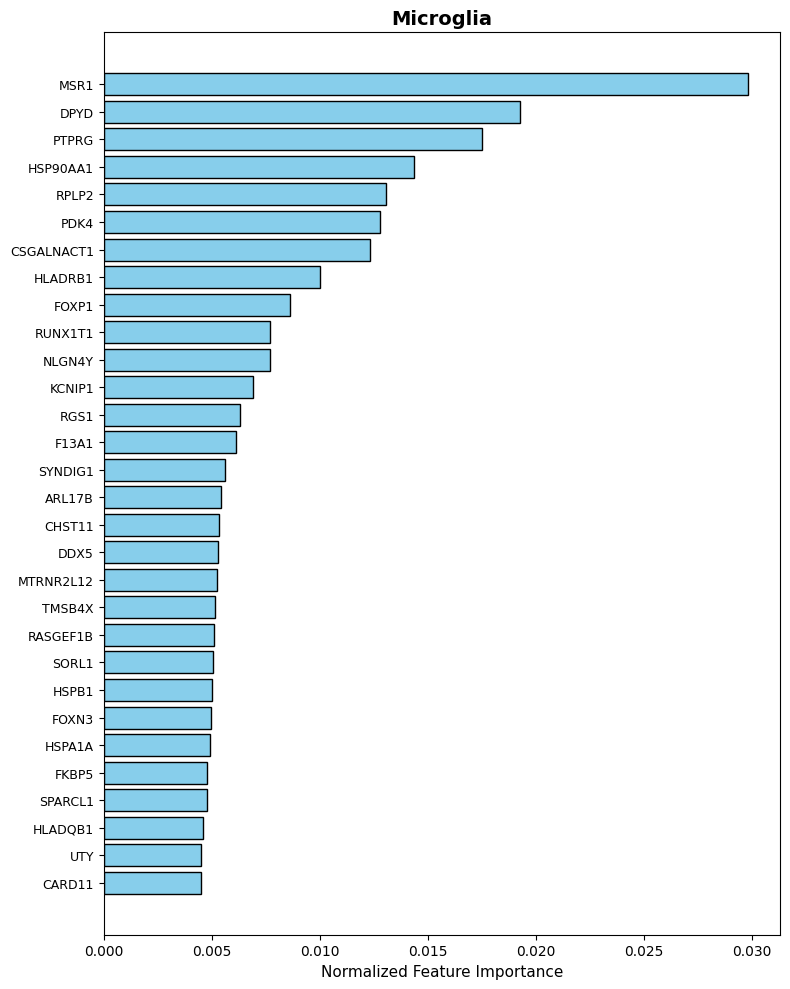

Saved plot for: Microglia
Processing: In

Feature importance for APOE across splits:
Split 1: 0
Split 2: 0
Split 3: 0
Split 4: 0
Split 5: 0


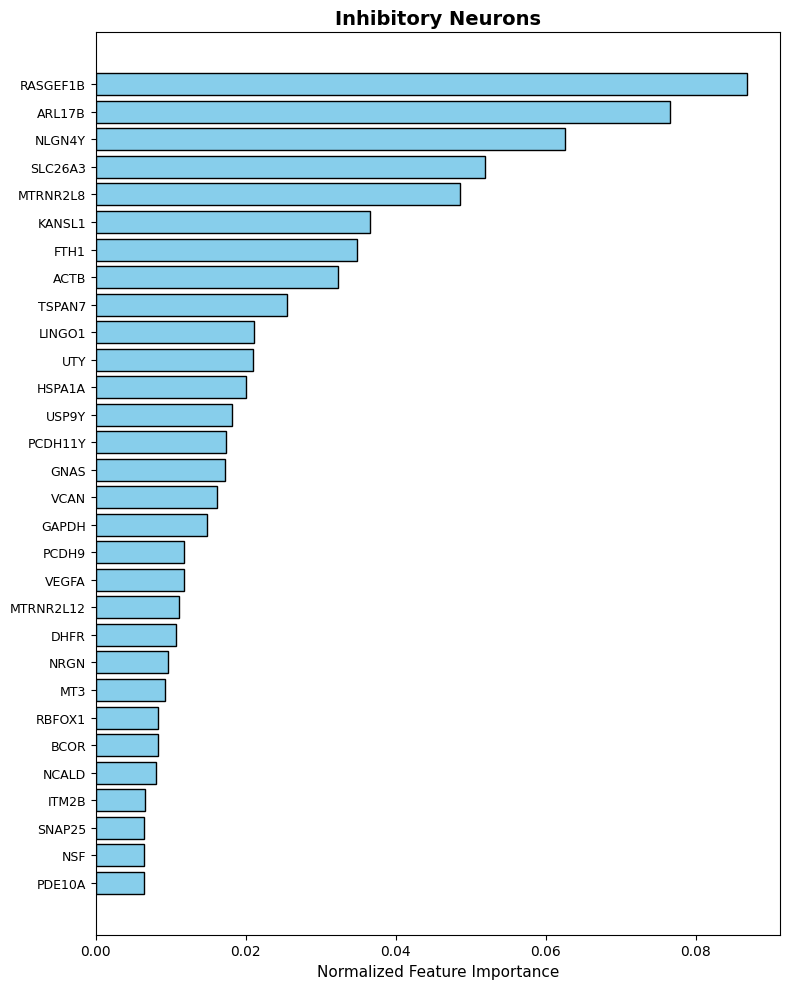

Saved plot for: Inhibitory Neurons
Processing: Oli

Feature importance for APOE across splits:
Split 1: 0.0
Split 2: 0.0
Split 3: 0.0
Split 4: 0.0
Split 5: 0.0


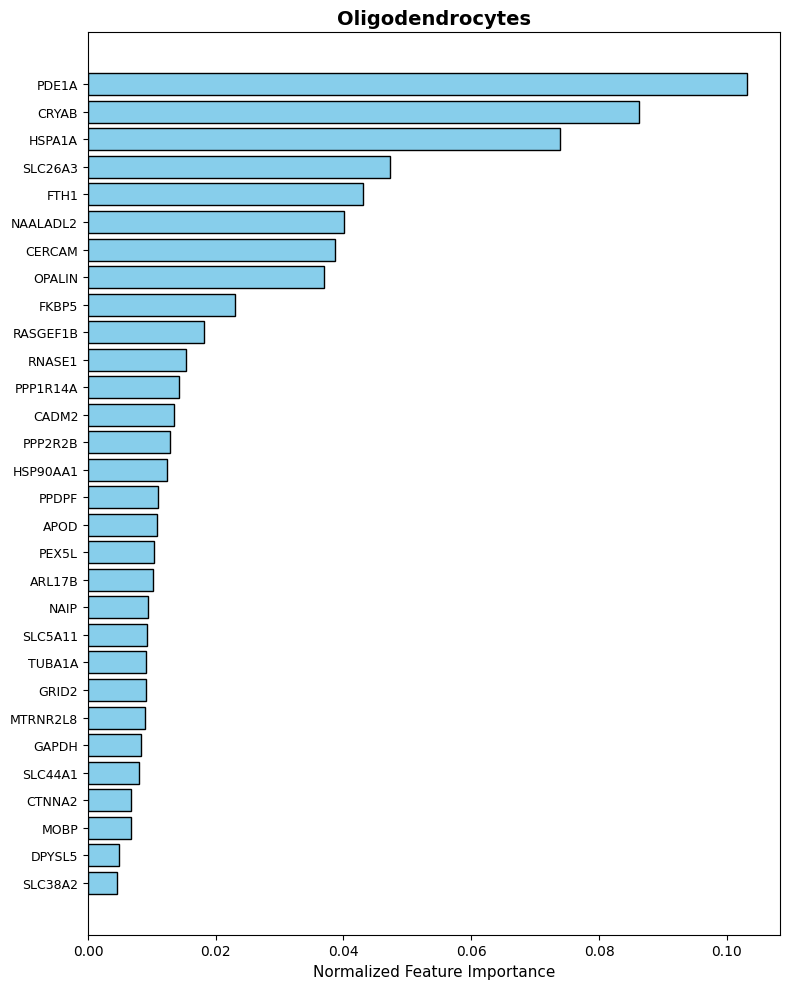

Saved plot for: Oligodendrocytes
Processing: Ex

Feature importance for APOE across splits:
Split 1: 0
Split 2: 0
Split 3: 0
Split 4: 0
Split 5: 0.0


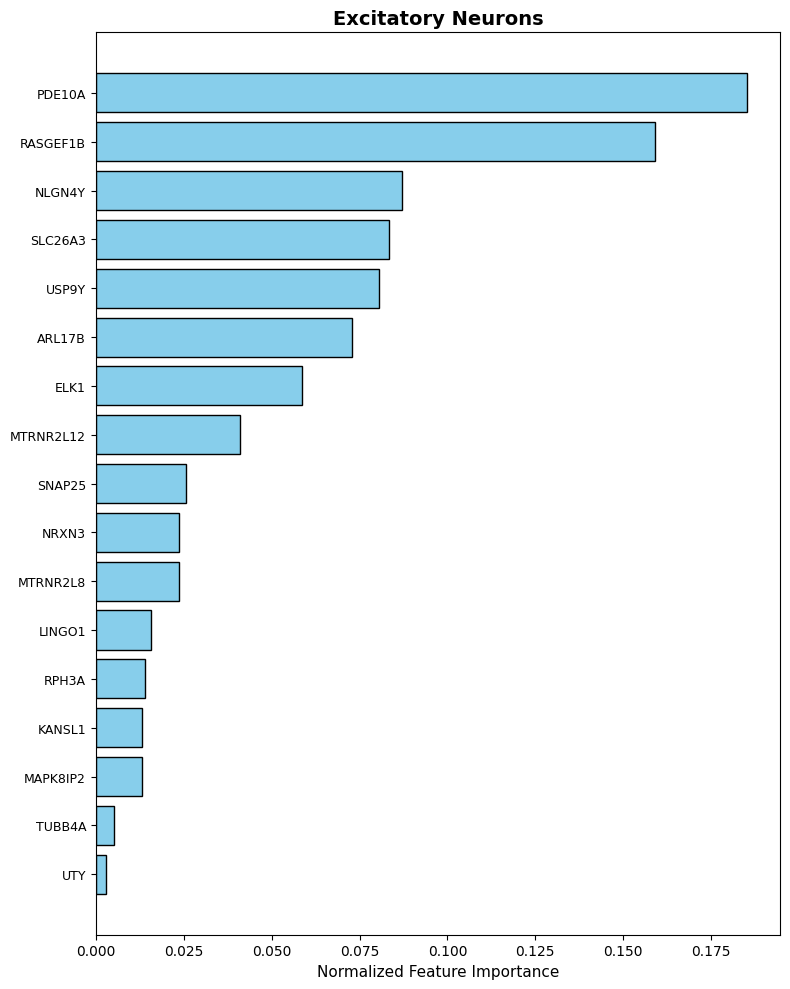

Saved plot for: Excitatory Neurons
 All plots finished and saved!


In [ ]:
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

# === Paths ===
base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Validation_Multirun_cell_on_cell_genes_Lau_rfe/"
output_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Validation_stuff/FeatureImportancePlots"
os.makedirs(output_dir, exist_ok=True)

# === Cell type labels ===
ct_labels = {
     'Ast': 'Astrocytes',
     'Mic': 'Microglia',
     'In': 'Inhibitory Neurons',
     'Oli': 'Oligodendrocytes',
     'Ex': 'Excitatory Neurons'
}
cell_types = list(ct_labels.keys())

# === Plotting function ===
def plot_feature_importance(features_df, cell_name, top_n=15):
    df_sorted = features_df.sort_values(by="Filtered_Mean", ascending=False).head(top_n)
    
    genes = df_sorted["Feature"]
    means = df_sorted["Filtered_Mean"]
    stds = df_sorted["Filtered_Std"]

    plt.figure(figsize=(8, 10))
    plt.barh(range(len(means)), means, color="skyblue", edgecolor="black")
    # plt.barh(range(len(means)), means, xerr=stds, color="skyblue", edgecolor="black")
    plt.yticks(range(len(means)), genes, fontsize=9)
    plt.xlabel("Normalized Feature Importance", fontsize=11)
    plt.title(cell_name, fontsize=14, fontweight="bold")
    plt.gca().invert_yaxis()  # most important on top
    plt.tight_layout()

    save_path = os.path.join(output_dir, f"{cell_name.replace(' ', '_')}_feature_importance.png")
    plt.savefig(save_path, dpi=300)
    plt.show()

    print(f"Saved plot for: {cell_name}")

# === Main loop ===
for cell_type in cell_types:
    print(f"Processing: {cell_type}")
    all_split_data = {}
    all_features = set()

    for split in range(1, 6):
        joblib_path = os.path.join(base_dir, cell_type, f"split_{split}", "maximal_classifier.joblib")
        if not os.path.exists(joblib_path):
            all_split_data[split] = {}
            continue

        model = joblib.load(joblib_path)
        feature_names = model.feature_names_in_
        importances = model.feature_importances_

        all_features.update(feature_names)
        all_split_data[split] = dict(zip(feature_names, importances))

        nonzero_imps = importances[importances > 0]
        # print(f"\nSplit {split} — Feature importance stats:")
        # print(f"  Total features: {len(importances)}")
        # print(f"  Non-zero features: {len(nonzero_imps)}")
        # print(f"  Mean importance (non-zero): {np.mean(nonzero_imps):.4f}")
        # print(f"  Max importance: {np.max(importances):.4f}")
        # print(f"  Median importance (non-zero): {np.median(nonzero_imps):.4f}")
        # print(f"  Std dev (non-zero): {np.std(nonzero_imps):.4f}")

    # --- Check importance values for PLXDC2 ---
    feature_to_check = "APOE"

    print(f"\nFeature importance for {feature_to_check} across splits:")
    for split in range(1, 6):
        imp = all_split_data.get(split, {}).get(feature_to_check, 0.0)
        print(f"Split {split}: {imp}")

    # Build dataframe rows
    table_rows = []
    sorted_features = sorted(list(all_features))

    for feature in sorted_features:
        raw_values = []
        filtered_norm_values = []

        for split in range(1, 6):
            raw_imp = all_split_data.get(split, {}).get(feature, 0.0)
            raw_values.append(raw_imp)

            all_imps_in_split = np.array(list(all_split_data.get(split, {}).values()))
            total_nonzero_imp = np.nansum(all_imps_in_split[all_imps_in_split > 0])

            if raw_imp > 0 and total_nonzero_imp > 0:
                norm_imp = raw_imp / total_nonzero_imp
            else:
                norm_imp = 0.0

            filtered_norm_values.append(norm_imp)

        filtered_mean = np.mean(filtered_norm_values)
        # filtered_mean = np.mean(raw_values)
        
        filtered_std = np.std(filtered_norm_values) / np.sqrt(len(filtered_norm_values))  # Use SEM instead of SD
        # filtered_std = np.std(filtered_norm_values)

        # Add to final row
        row_data = {
            "Feature": feature,
            "Filtered_Mean": filtered_mean,
            "Filtered_Std": filtered_std
        }
        if np.sum(np.array(raw_values) > 0) > 1:
            table_rows.append(row_data)

    # Convert to dataframe
    features_df = pd.DataFrame(table_rows)

    # Plot
    plot_feature_importance(features_df, ct_labels[cell_type])

print(" All plots finished and saved!")

Opc: 259 predictive genes
Ex: 1 predictive genes
Astrocytes — Overlap: 112, p-value: 1.473e-51, odds ratio: 8.16
Top overlapping genes in Astrocytes: ABCC9, ACAP2, ADAR, ADGRA3, ANGPTL4, ARHGAP24, ARL17B, B4GALNT4, BAG3, BAZ1B
Microglia — Overlap: 19, p-value: 1.588e-07, odds ratio: 4.69
Top overlapping genes in Microglia: ARHGAP15, C1QC, CD14, CSF2RA, CTTNBP2NL, DPYD, FCHSD2, FOXP1, GPR34, HSPA1A
Inhibitory Neurons — Overlap: 52, p-value: 2.758e-42, odds ratio: 20.72
Top overlapping genes in Inhibitory Neurons: ACTB, AKAP9, ARL17B, ATP1B1, ATP2A2, ATRNL1, BCOR, BEX1, BEX2, CALM1
Oligodendrocytes — Overlap: 98, p-value: 3.322e-67, odds ratio: 15.44
Top overlapping genes in Oligodendrocytes: ABL1, ACSL4, ADARB2, ADIPOR2, AMER2, ANK3, ANO4, ARL17B, ARMC8, ASTN2
Oligodendrocyte Progenitor Cells — Overlap: 39, p-value: 2.776e-13, odds ratio: 4.62
Top overlapping genes in Oligodendrocyte Progenitor Cells: ARFGEF2, ARL17B, ASB3, BICD1, CABP1, CNTN4, COL4A3, DNM1, EEF2K, FTH1
Excitatory Neurons — Overlap: 1, p-value: 6.136e-03, odds ratio: inf
Top overlapping genes in Excitatory Neurons: ARL17B

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc_curves_with_variability(cell_type, cell_name):
    base_dirs = {
        # 'Combined': f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_both_cerad/{cell_type}',
        'Genes': f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Validation_Multirun_cell_on_cell_genes_Lau_rfe/{cell_type}',
        # 'Demo + APOE': f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_demo_cerad/{cell_type}',
        'APOE + Genes': f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Validation_Multirun_cell_on_cell_genes_APOE_genes/{cell_type}',
    }

    colors = {
        'Combined': 'black',
        'Genes': 'blue',
        'Demo + APOE': 'red',
        'APOE + Genes': '#66c2a5',
    }

    plt.figure(figsize=(8, 6))
    mean_fpr = np.linspace(0, 1, 100)

    for label, base_path in base_dirs.items():
        all_tprs = []
        aucs = []

        for i in range(1, 6):
            pred_file = os.path.join(base_path, f'split_{i}', 'test_predictions.csv')
            if not os.path.exists(pred_file):
                continue

            df = pd.read_csv(pred_file)
            y_true = df['true_label']
            y_score = df['predicted_proba']
            fpr, tpr, _ = roc_curve(y_true, y_score)
            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0
            all_tprs.append(interp_tpr)
            aucs.append(auc(fpr, tpr))

            plt.plot(fpr, tpr, color=colors[label], alpha=0.2)
            # plt.plot(fpr, tpr, alpha=0.2, label=f'{label} split {i}')

        if all_tprs:
            mean_tpr = np.mean(all_tprs, axis=0)
            mean_auc = np.mean(aucs)
            std_auc = np.std(aucs)
            plt.plot(mean_fpr, mean_tpr, color=colors[label], linewidth=2.5,
                     label=f'{label} (AUC: {mean_auc:.3f} ± {std_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
    plt.title(cell_name, fontsize=16, fontweight='bold')
    plt.xticks(fontsize=12, fontweight='bold')
    plt.yticks(fontsize=12, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11, frameon=True)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    # Save figure
    save_dir = f"/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Validation_stuff/"
    os.makedirs(save_dir, exist_ok=True)
    output_path = os.path.join(save_dir, f'{cell_type}_roc_curve.png')
    plt.savefig(output_path, dpi=300)
    plt.show()

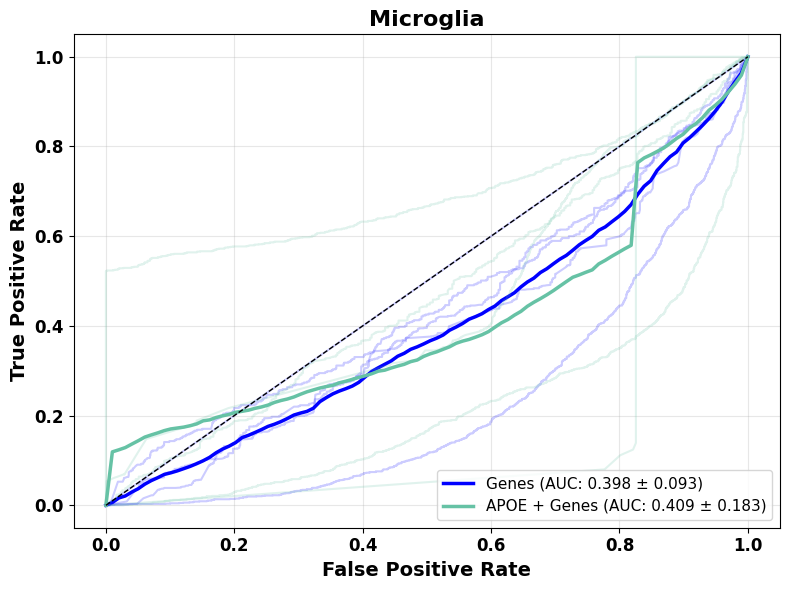

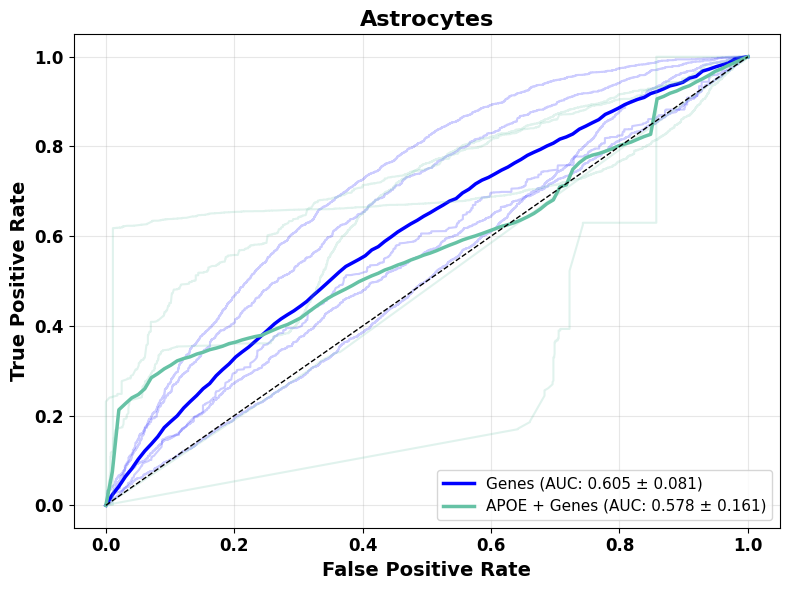

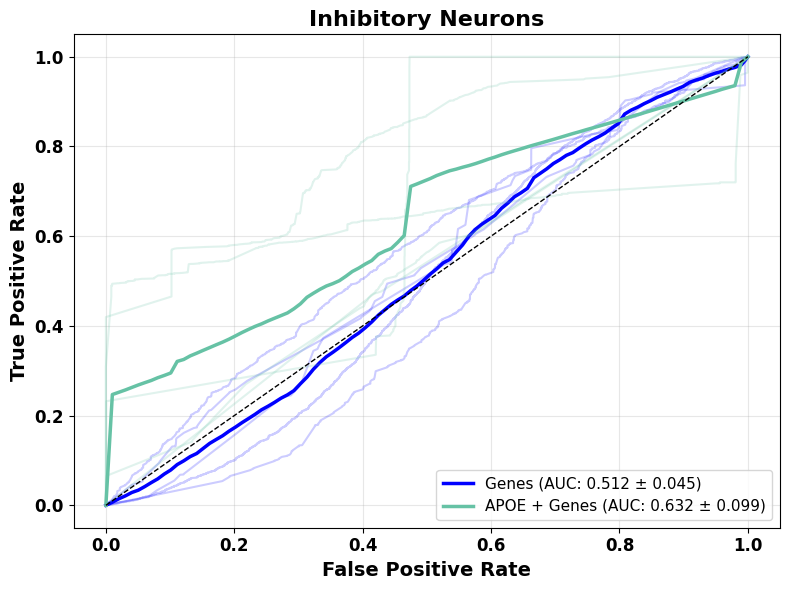

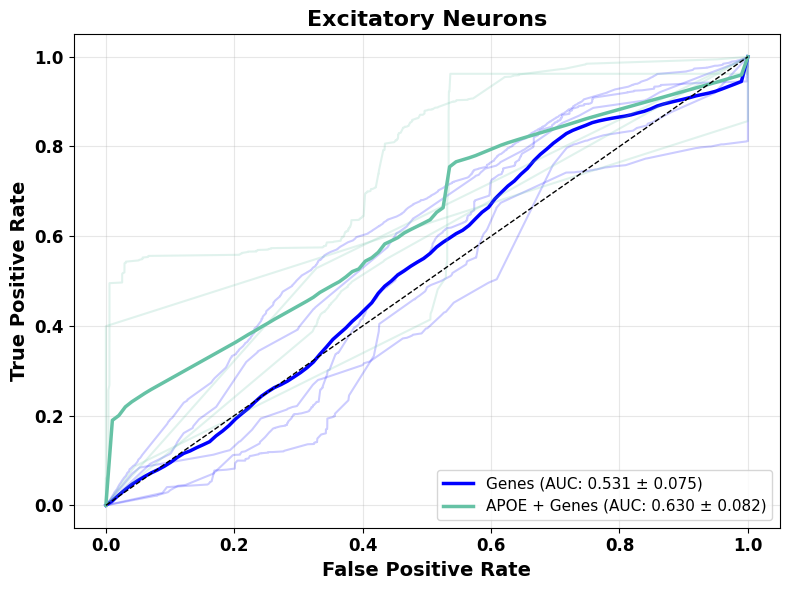

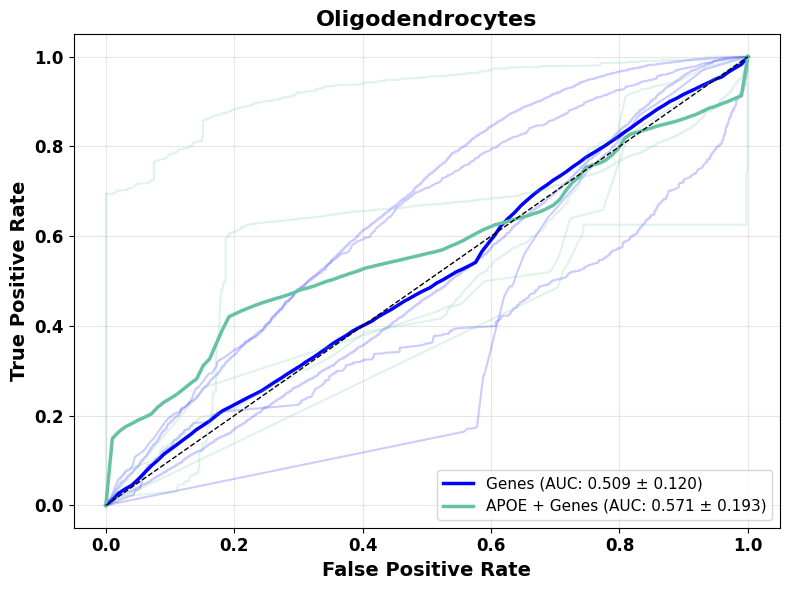

In [4]:
plot_roc_curves_with_variability('Mic', 'Microglia')
plot_roc_curves_with_variability('Ast', 'Astrocytes')
plot_roc_curves_with_variability('In', 'Inhibitory Neurons')
plot_roc_curves_with_variability('Ex', 'Excitatory Neurons')
#plot_roc_curves_with_variability('Opc', 'Oligodendrocyte Progenitor Cells')
plot_roc_curves_with_variability('Oli', 'Oligodendrocytes')

In [ ]:
cells = pd.read_parquet("Validation_Metadata_Final_with_celltypes.parquet")

In [1]:
import os
import joblib
from collections import defaultdict
import pandas as pd
from scipy.stats import fisher_exact

# === Load background genes ===
gene_matrix = pd.read_parquet('/home/adm808/NormalizedCellMatrixSyn18485175.parquet')
background_genes = set(gene_matrix.index.str.upper())
print(f"Total background genes: {len(background_genes)}")

# === Define cell types ===
ct_labels = {
    'Ast': 'Astrocytes',
    'Mic': 'Microglia',
    'In': 'Inhibitory Neurons',
    'Oli': 'Oligodendrocytes',
    'Ex': 'Excitatory Neurons'
}
cell_types = list(ct_labels.keys())

# === Function to collect predictive genes and counts ===
def collect_predictive_genes_with_counts(base_dir, cell_types, n_splits):
    gene_counts = {}
    for cell_type in cell_types:
        gene_presence = defaultdict(int)
        for split in range(1, n_splits + 1):
            joblib_path = os.path.join(base_dir, cell_type, f"split_{split}", "maximal_classifier.joblib")
            if not os.path.exists(joblib_path):
                continue
            model = joblib.load(joblib_path)
            feature_names = model.feature_names_in_
            importances = model.feature_importances_
            for gene, imp in zip(feature_names, importances):
                if imp > 0:
                    gene_presence[gene.upper()] += 1
        gene_counts[cell_type] = dict(gene_presence)
        print(f"{cell_type}: {len([g for g, c in gene_presence.items() if c >= 2])} predictive genes (≥2 splits)")
    return gene_counts

# === Collect predictors ===
ad_base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
ad_counts = collect_predictive_genes_with_counts(ad_base_dir, cell_types, 5)

cerad_base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Validation_Multirun_cell_on_cell_genes_Lau_rfe"
cerad_counts = collect_predictive_genes_with_counts(cerad_base_dir, cell_types, 5)

# === Fisher exact test summary table ===
results = []

# === Excel writer ===
excel_path = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Data/Validation_overlap_results.xlsx"
writer = pd.ExcelWriter(excel_path, engine='xlsxwriter')

# === Add description sheet ===
description_text = (
    "This Excel workbook summarizes the overlap of predictive genes between the original dataset "
    "and the validation dataset, analyzed across different cell types.\n\n"
    "For each cell type:\n"
    "- We collect genes that are predictive (appear in ≥2 splits).\n"
    "- We compute overlaps between the original and validation sets.\n"
    "- We perform Fisher's exact test to assess enrichment of overlap.\n\n"
    "The 'Fisher_Results' sheet summarizes overall statistics.\n"
    "Each cell-type-specific sheet lists genes, split counts, and whether the gene is concordant."
)

# Create a DataFrame with a single column to hold the text
desc_df = pd.DataFrame({'Description': description_text.split('\n')})
desc_df.to_excel(writer, sheet_name='Description', index=False)

for cell_type in cell_types:
    ad_dict = ad_counts[cell_type]
    cerad_dict = cerad_counts[cell_type]

    ad_genes = set([gene for gene, count in ad_dict.items() if count >= 2])
    cerad_genes = set([gene for gene, count in cerad_dict.items() if count >= 2])
    overlap = ad_genes & cerad_genes

    # Fisher test
    a = len(overlap)
    b = len(ad_genes - overlap)
    c = len(cerad_genes - overlap)
    d = len(background_genes - (ad_genes | cerad_genes))
    table = [[a, b], [c, d]]
    odds_ratio, p_value = fisher_exact(table, alternative='greater')

    results.append({
        'CellType': ct_labels[cell_type],
        'Original Dataset AD Predictive Genes': len(ad_genes),
        'Validation Dataset AD Predictive Genes': len(cerad_genes),
        'Overlap': a,
        'OddsRatio': odds_ratio,
        'PValue': p_value
    })

    # === Build detailed gene table for this cell type ===
    gene_rows = []
    for gene in sorted(background_genes):
        orig_splits = ad_dict.get(gene, 0)
        val_splits = cerad_dict.get(gene, 0)
        pred_orig = orig_splits >= 2
        pred_val = val_splits >= 2
        overlap_flag = pred_orig and pred_val
        gene_rows.append({
            'Gene': gene,
            'Predictive_in_Original': pred_orig,
            'Predictive_in_Validation': pred_val,
            'Overlapping': overlap_flag,
            'Original_Splits': orig_splits,
            'Validation_Splits': val_splits
        })

    gene_df = pd.DataFrame(gene_rows)
    gene_df.to_excel(writer, sheet_name=ct_labels[cell_type][:31], index=False)

# === Save Fisher summary table as first sheet ===
results_df = pd.DataFrame(results)
results_df.to_excel(writer, sheet_name='Fisher_Results', index=False)

# === Save workbook ===
writer.close()
print(f"Excel workbook saved to {excel_path}")

Total background genes: 17926
Ast: 175 predictive genes (≥2 splits)
Mic: 466 predictive genes (≥2 splits)
In: 108 predictive genes (≥2 splits)
Oli: 621 predictive genes (≥2 splits)
Ex: 162 predictive genes (≥2 splits)
Ast: 212 predictive genes (≥2 splits)
Mic: 274 predictive genes (≥2 splits)
In: 50 predictive genes (≥2 splits)
Oli: 268 predictive genes (≥2 splits)
Ex: 17 predictive genes (≥2 splits)
Excel workbook saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Data/Validation_overlap_results.xlsx


In [ ]:
import os
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import is_classifier
import matplotlib.pyplot as plt

# ============================
# Paths / IO
# ============================
genes_only_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
genes_apoe_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_apoe_new"

val_expr_path = "/n/groups/patel/adithya/Validation_ExpressionMatrix_Final_Normalized.parquet"
val_meta_path = "/n/groups/patel/adithya/Validation_Metadata_Final.parquet"

save_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure6/Mathys_on_validation/OVERLAY_ONE_SHOT_genes_vs_APOE"
os.makedirs(save_dir, exist_ok=True)

# ============================
# Config
# ============================
cell_types = ['Mic', 'Ast', 'In', 'Ex', 'Oli']
splits = [1, 2, 3, 4, 5]
top_ks = list(range(1, 26))  # top_1 .. top_25
APOE_PREFIX = "apoe_genotype_"

# ============================
# Load validation data
# ============================
val_expr = pd.read_parquet(val_expr_path)
val_expr.columns = val_expr.columns.astype(str)

val_meta = pd.read_parquet(val_meta_path).set_index("TAG")
if "alzheimers_or_control" not in val_meta.columns:
    raise ValueError("Missing 'alzheimers_or_control' in validation metadata.")

# Precompute APOE one-hots over full meta; will subset per CT
if "apoe_genotype" in val_meta.columns:
    apoe_dummies_full = pd.get_dummies(val_meta["apoe_genotype"], prefix="apoe_genotype").astype(np.float32)
else:
    # If APOE is missing in validation meta, create empty frame so builder can zero-pad
    apoe_dummies_full = pd.DataFrame(index=val_meta.index)

# ============================
# Helpers
# ============================
def build_X_genes(model_features, expr_sub):
    """Builds X from expression only; zero-pads missing features; preserves order."""
    available = [f for f in model_features if f in expr_sub.columns]
    missing = [f for f in model_features if f not in expr_sub.columns]
    X = expr_sub[available].copy()
    if missing:
        pad = pd.DataFrame(0.0, index=X.index, columns=missing)
        X = pd.concat([X, pad], axis=1)
    return X[model_features].astype(np.float32)

def build_X_genes_apoe(model_features, expr_sub, apoe_sub):
    """
    Builds X from expression + APOE one-hots. If a feature is not in either,
    it is zero-padded. Preserves order of model_features.
    """
    expr_cols = set(expr_sub.columns)
    apoe_cols = set(apoe_sub.columns)
    parts = {}
    for f in model_features:
        if f in expr_cols:
            parts[f] = expr_sub[f].astype(np.float32)
        elif f in apoe_cols:
            parts[f] = apoe_sub[f].astype(np.float32)
        else:
            parts[f] = pd.Series(0.0, index=expr_sub.index, dtype=np.float32)
    return pd.DataFrame(parts, index=expr_sub.index, columns=model_features)

def best_one_shot_for_dir(base_dir, cell_type, val_expr_sub, val_meta_sub, builder_func, apoe_sub=None):
    """
    Sweep all (k, split) under base_dir/CT, build X via builder_func,
    fit isotonic on full CT validation set, prior-reweight, compute AUC,
    and return the best (k, split, y_true, y_prob, AUC).
    """
    best_auc = -1.0
    best = {"topk": None, "split": None, "y_true": None, "y_prob": None, "auc": None}

    for topk in top_ks:
        for split in splits:
            model_path = os.path.join(base_dir, cell_type, f"split_{split}",
                                      f"top_{topk}_features_classifier.joblib")
            if not os.path.exists(model_path):
                continue
            try:
                clf = joblib.load(model_path)
                if not hasattr(clf, "model") or not is_classifier(clf.model):
                    continue
                feats = list(clf.feature_names_in_)

                # Build features (genes-only or genes+APOE)
                if apoe_sub is None:
                    X_val = build_X_genes(feats, val_expr_sub)
                else:
                    X_val = build_X_genes_apoe(feats, val_expr_sub, apoe_sub)

                y_val = val_meta_sub.loc[X_val.index, 'alzheimers_or_control'].astype(int)

                # Isotonic calibration on full CT validation set
                calibrator = CalibratedClassifierCV(clf.model, method='isotonic', cv='prefit')
                calibrator.fit(X_val, y_val)
                y_prob = calibrator.predict_proba(X_val)[:, 1]

                # Prior reweighting (kept exactly as before)
                p_val = y_val.mean()
                eps = 1e-6
                y_prob_rw = (y_prob * (p_val + eps)) / (
                    y_prob * (p_val + eps) + (1 - y_prob) * (1 - p_val + eps)
                )

                auc_val = roc_auc_score(y_val, y_prob_rw)

                if auc_val > best_auc:
                    best_auc = auc_val
                    best = {
                        "topk": topk,
                        "split": split,
                        "y_true": y_val.values,
                        "y_prob": y_prob_rw,
                        "auc": float(auc_val)
                    }
            except Exception as e:
                print(f"  {cell_type} {os.path.basename(base_dir)} split {split} k={topk}: {e}")
                continue

    return best

# ============================
# Run & Plot
# ============================
summary_rows = []

for ct in cell_types:
    print(f"\n🔬 {ct}: computing best one-shot for genes-only and genes+APOE")

    meta_ct = val_meta[val_meta['broad.cell.type'] == ct].copy()
    if meta_ct.empty:
        print("  ⚠️ No validation cells; skipping.")
        continue
    idx = meta_ct.index
    expr_ct = val_expr.loc[idx]

    # APOE dummies subset (may be empty if APOE not in meta)
    if not apoe_dummies_full.empty:
        apoe_ct = apoe_dummies_full.reindex(index=idx).fillna(0.0).astype(np.float32)
    else:
        apoe_ct = pd.DataFrame(index=idx)  # empty -> builder will zero-pad

    # --- Best genes-only ---
    best_genes = best_one_shot_for_dir(
        genes_only_dir, ct, expr_ct, meta_ct, builder_func=build_X_genes, apoe_sub=None
    )
    if best_genes["y_prob"] is None:
        print("  ⚠️ No successful genes-only models; skipping CT.")
        continue

    # --- Best genes+APOE ---
    best_apoe = best_one_shot_for_dir(
        genes_apoe_dir, ct, expr_ct, meta_ct, builder_func=build_X_genes_apoe, apoe_sub=apoe_ct
    )
    if best_apoe["y_prob"] is None:
        print("  ⚠️ No successful genes+APOE models; plotting genes-only only.")

    # --- Plot overlay for this CT ---
    fig, ax = plt.subplots(figsize=(5.8, 5.4))

    # Genes-only curve (solid red)
    fpr_g, tpr_g, _ = roc_curve(best_genes["y_true"], best_genes["y_prob"])
    auc_g = auc(fpr_g, tpr_g)
    ax.plot(fpr_g, tpr_g, linewidth=2,
            label=f"Genes-only One-Shot AUC = {auc_g:.2f}")

    # Genes+APOE curve (solid blue) if available
    if best_apoe["y_prob"] is not None:
        fpr_a, tpr_a, _ = roc_curve(best_apoe["y_true"], best_apoe["y_prob"])
        auc_a = auc(fpr_a, tpr_a)
        ax.plot(fpr_a, tpr_a, linewidth=2,
                label=f"Genes+APOE One-Shot AUC = {auc_a:.2f}")

    # Diagonal + cosmetics
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.7)
    ax.set_title(f"{ct} — One-Shot Overlay")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    plt.tight_layout()

    out_png = os.path.join(
        save_dir,
        f"{ct}_overlay_one_shot_genes_vs_apoe"
        f"_genesTop{best_genes['topk']}_split{best_genes['split']}"
        f"{'_apoeTop'+str(best_apoe['topk'])+'_split'+str(best_apoe['split']) if best_apoe['y_prob'] is not None else ''}.png"
    )
    plt.savefig(out_png, dpi=300)
    plt.close(fig)
    print(f" Saved: {out_png}  (Genes-only AUC={best_genes['auc']:.3f}"
          f"{', Genes+APOE AUC='+format(best_apoe['auc'], '.3f') if best_apoe['y_prob'] is not None else ''})")

    # Summary row
    summary_rows.append({
        "CellType": ct,
        "GenesOnly_BestTopK": best_genes["topk"],
        "GenesOnly_BestSplit": best_genes["split"],
        "GenesOnly_OneShot_AUC": best_genes["auc"],
        "APOE_BestTopK": best_apoe["topk"],
        "APOE_BestSplit": best_apoe["split"],
        "APOE_OneShot_AUC": best_apoe["auc"] if best_apoe["y_prob"] is not None else np.nan,
        "N_ValCells": int(len(meta_ct)),
        "N_ValDonors": int(meta_ct['projid'].nunique()) if 'projid' in meta_ct.columns else np.nan
    })

# ============================
# Save summary
# ============================
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(save_dir, "overlay_one_shot_genes_vs_apoe_summary.csv")
summary_df.to_csv(summary_csv, index=False)
print(f"\n Wrote summary: {summary_csv}")
print(summary_df)

Astrocytes — Overlap: 27, p-value: 2.706e-22, odds ratio: 26.42
Top overlapping genes in Astrocytes: ANGPTL4, ARL17B, B4GALNT4, CALN1, CIRBP, COL21A1, CSRP1, DLC1, GFAP, HSPB1
Microglia — Overlap: 40, p-value: 1.837e-15, odds ratio: 5.44
Top overlapping genes in Microglia: ADAP2, ANKS1A, APOE, ARHGAP15, ATP8B4, CD74, CHD1, DPYD, EEA1, ETS2
Inhibitory Neurons — Overlap: 172, p-value: 2.430e-40, odds ratio: 3.97
Top overlapping genes in Inhibitory Neurons: AES, AGBL4, AHI1, AHSA1, ANKRD30BL, AP1G2, APBB2, APOO, APTX, ARL15
Oligodendrocytes — Overlap: 131, p-value: 1.671e-69, odds ratio: 11.29
Top overlapping genes in Oligodendrocytes: ABCA8, ABL1, ACSL4, ACYP2, ADARB2, ADCY5, AMER2, ANK3, ANO4, ARL17B
Oligodendrocyte Progenitor Cells — Overlap: 0, p-value: 1.000e+00, odds ratio: nan
Top overlapping genes in Oligodendrocyte Progenitor Cells: 
Excitatory Neurons — Overlap: 48, p-value: 1.373e-33, odds ratio: 15.67
Top overlapping genes in Excitatory Neurons: ARL17B, ARPP19, ASIC2, CABP1, CALM1, CAMK2B, CHORDC1, DHFR, EEF1A1, EIF4A2


Processing Ast


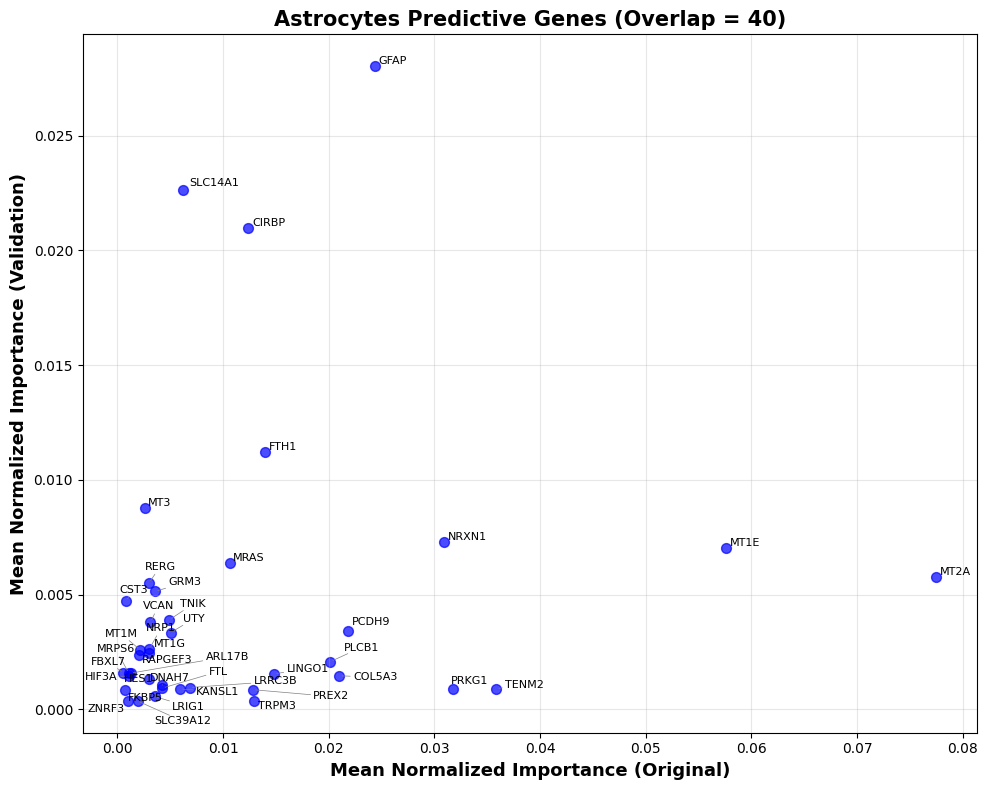


Processing Mic


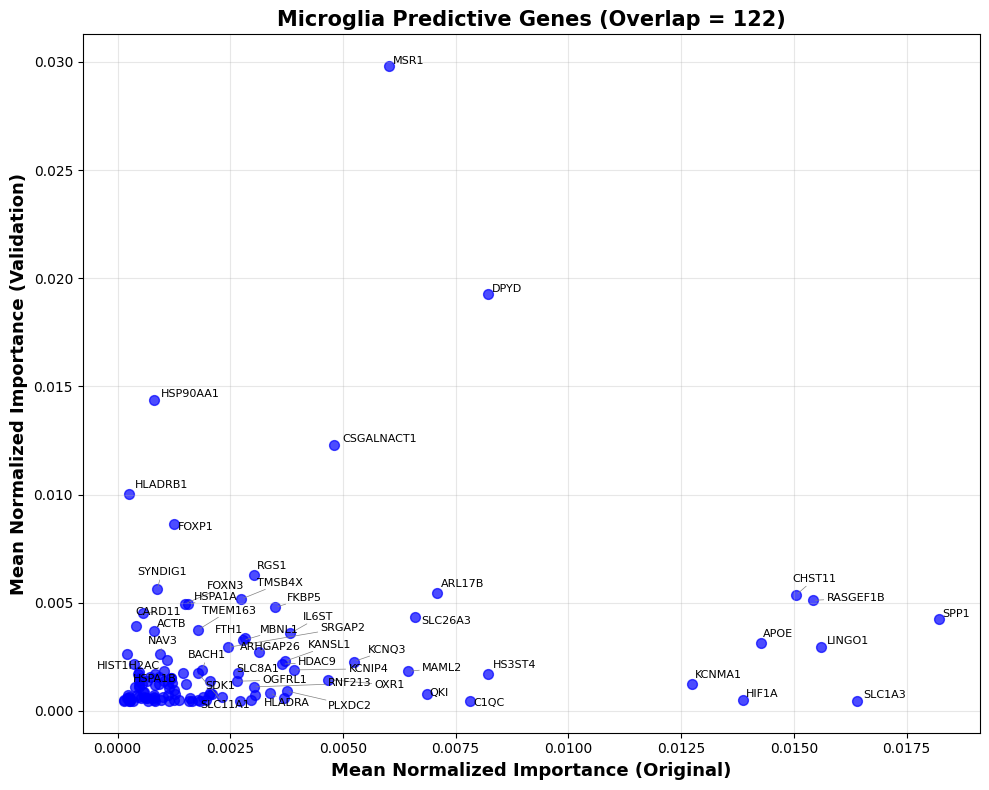


Processing In


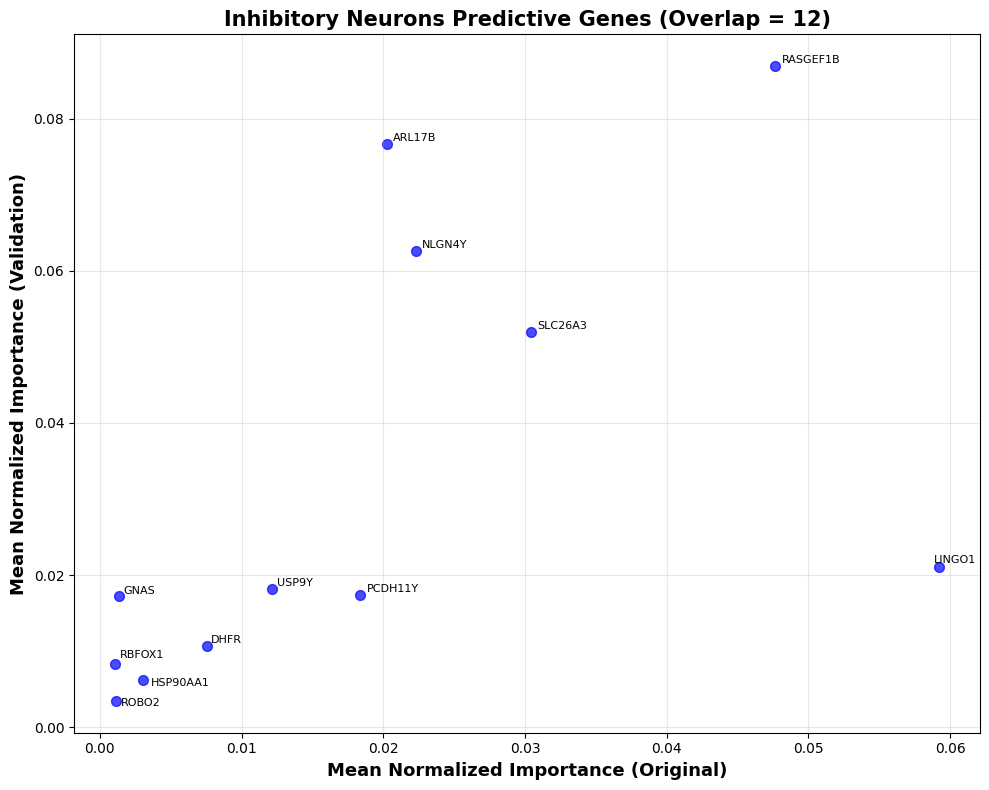


Processing Oli


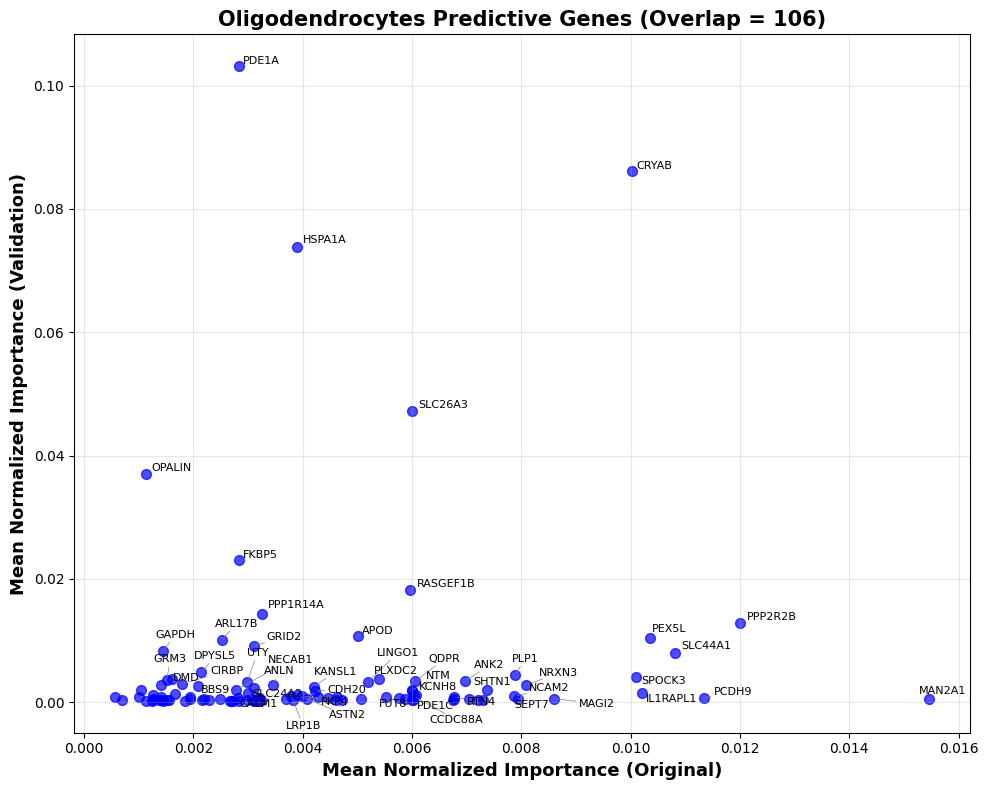


Processing Ex


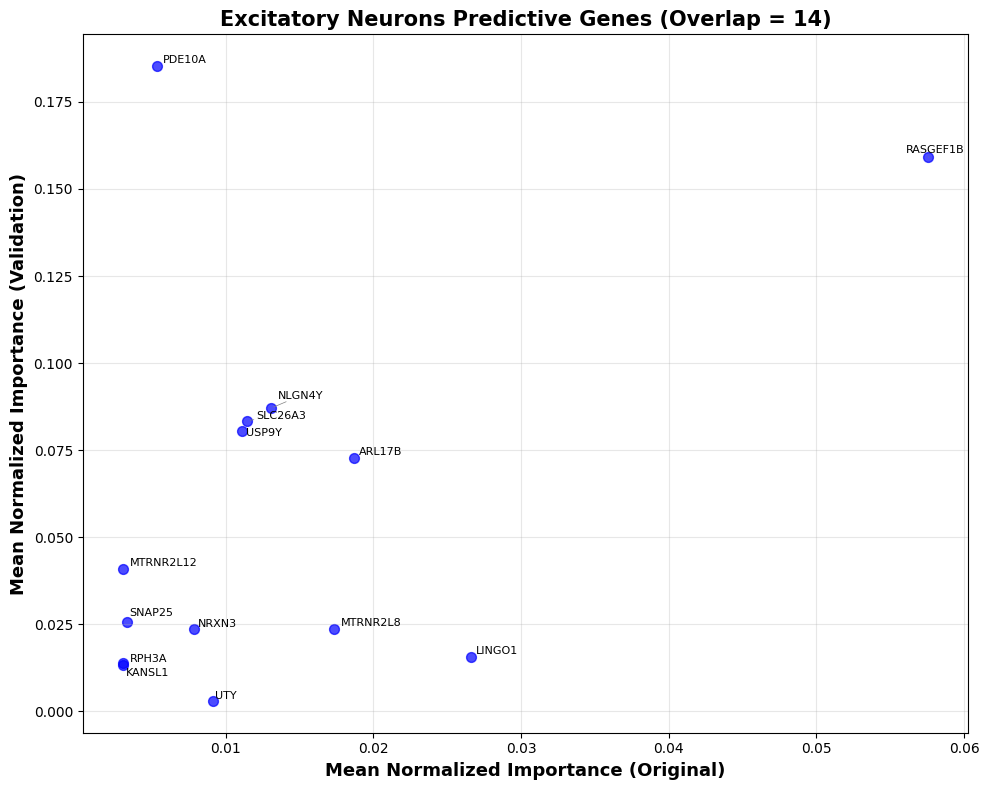


All plots finished!


In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from adjustText import adjust_text

# === Paths ===
ad_base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
cerad_base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Validation_Multirun_cell_on_cell_genes_Lau_rfe"
n_splits = 5

# === Cell types to iterate ===
ct_labels = {
    'Ast': 'Astrocytes',
    'Mic': 'Microglia',
    'In': 'Inhibitory Neurons',
    'Oli': 'Oligodendrocytes',
    'Ex': 'Excitatory Neurons'
}
cell_types = list(ct_labels.keys())

# === Helper function ===
def get_mean_normalized_importances(base_dir, cell_type, n_splits):
    gene_norm_importances = defaultdict(list)

    for split in range(1, n_splits + 1):
        joblib_path = os.path.join(base_dir, cell_type, f"split_{split}", "maximal_classifier.joblib")
        if not os.path.exists(joblib_path):
            continue
        model = joblib.load(joblib_path)
        feature_names = model.feature_names_in_
        importances = model.feature_importances_

        total_nonzero = np.sum(importances[importances > 0])
        for gene, imp in zip(feature_names, importances):
            if imp > 0 and total_nonzero > 0:
                norm_imp = imp / total_nonzero
            else:
                norm_imp = 0.0
            gene_norm_importances[gene.upper()].append(norm_imp)

    # Mean across splits
    mean_norms = {gene: np.mean(vals) for gene, vals in gene_norm_importances.items()}
    return mean_norms, gene_norm_importances

# === Iterate through each cell type ===
for cell_type in cell_types:
    print(f"\nProcessing {cell_type}")

    # Get importances
    ad_means, ad_counts_dict = get_mean_normalized_importances(ad_base_dir, cell_type, n_splits)
    cerad_means, cerad_counts_dict = get_mean_normalized_importances(cerad_base_dir, cell_type, n_splits)

    # Define predictors
    ad_predictors = set([gene for gene, counts in ad_counts_dict.items() if sum(np.array(counts) > 0) >= 2])
    cerad_predictors = set([gene for gene, counts in cerad_counts_dict.items() if sum(np.array(counts) > 0) >= 2])
    overlap_genes = ad_predictors & cerad_predictors

    # Build plot dataframe
    data = []
    for gene in overlap_genes:
        x_val = ad_means.get(gene, 0)
        y_val = cerad_means.get(gene, 0)
        geom_mean = np.sqrt(x_val * y_val)  # Metric for ranking
        data.append((gene, x_val, y_val, geom_mean))

    plot_df = pd.DataFrame(data, columns=["Gene", "Mathys_Mean_Importance", "Validation_Mean_Importance", "Geom_Mean"])

    # Skip if no overlap
    if plot_df.empty:
        print("No overlapping genes — skipping plot.")
        continue

    # === Plotting ===
    plt.figure(figsize=(10, 8))
    plt.scatter(
        plot_df["Mathys_Mean_Importance"],
        plot_df["Validation_Mean_Importance"],
        color='blue',
        alpha=0.7,
        s=50
    )

    # Label top 50 genes by geometric mean
    top_genes_df = plot_df.sort_values(by="Geom_Mean", ascending=False).head(50)
    texts = []
    for _, row in top_genes_df.iterrows():
        texts.append(
            plt.text(
                row["Mathys_Mean_Importance"],
                row["Validation_Mean_Importance"],
                row["Gene"],
                fontsize=8
            )
        )

    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    # Axis labels and title
    overlap_count = len(plot_df)
    title = f"{ct_labels[cell_type]} Predictive Genes (Overlap = {overlap_count})"
    plt.xlabel("Mean Normalized Importance (Original)", fontsize=13, fontweight='bold')
    plt.ylabel("Mean Normalized Importance (Validation)", fontsize=13, fontweight='bold')
    plt.title(title, fontsize=15, fontweight='bold')
    plt.grid(alpha=0.3)
    plt.tight_layout()

    # Save plot
    save_path = f"/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure6/Validation_stuff_new/{cell_type}_importance_scatter.png"
    plt.savefig(save_path, dpi=300)
    plt.show()

print("\nAll plots finished!")

Astrocytes: Overlap genes saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Differential_Expression_Final/Overlap_Tables/Validation/overlap_pred_DE_Ast.csv


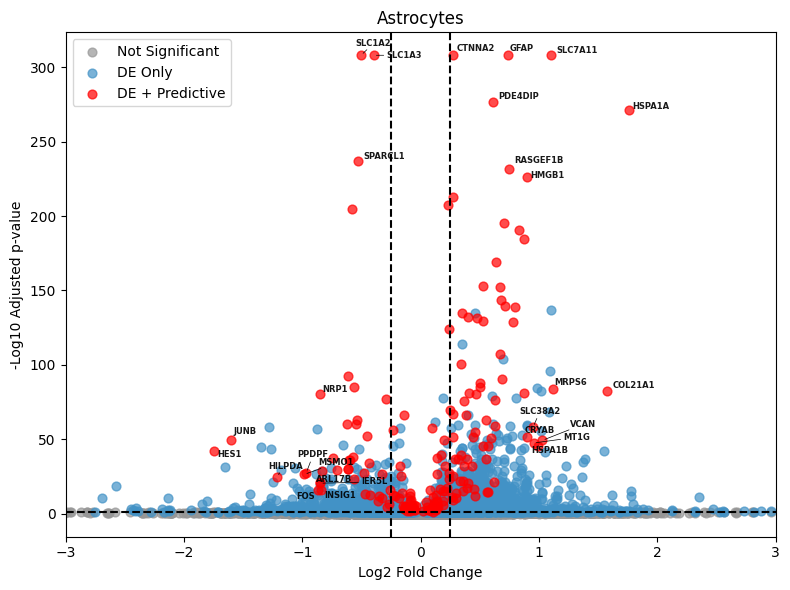

Astrocytes: Volcano plot saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure6/Validation_DE/volcano_Ast_pred_marked.png
Microglia: Overlap genes saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Differential_Expression_Final/Overlap_Tables/Validation/overlap_pred_DE_Mic.csv


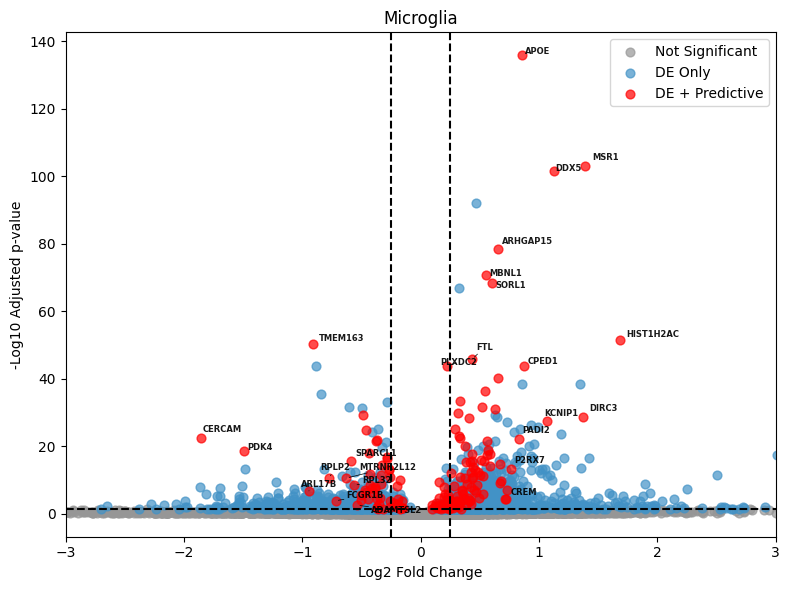

Microglia: Volcano plot saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure6/Validation_DE/volcano_Mic_pred_marked.png
Inhibitory Neurons: Overlap genes saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Differential_Expression_Final/Overlap_Tables/Validation/overlap_pred_DE_In.csv


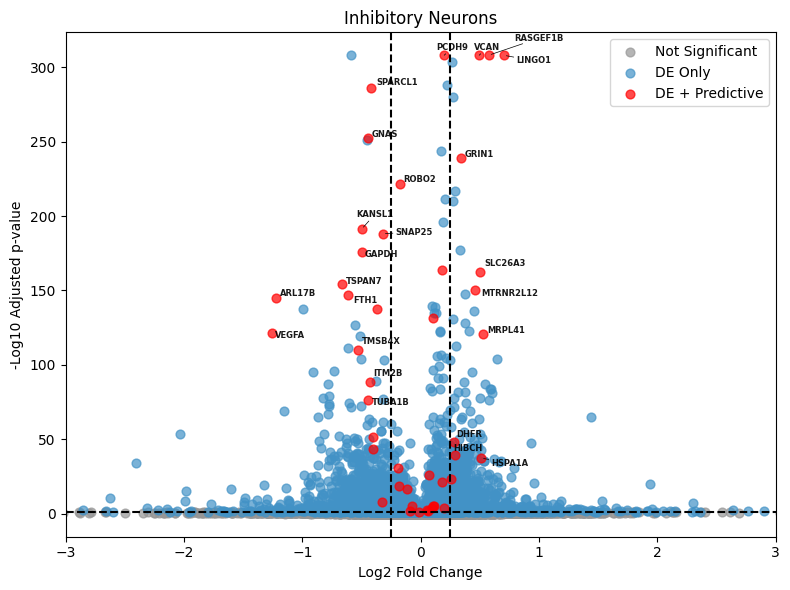

Inhibitory Neurons: Volcano plot saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure6/Validation_DE/volcano_In_pred_marked.png
Oligodendrocytes: Overlap genes saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Differential_Expression_Final/Overlap_Tables/Validation/overlap_pred_DE_Oli.csv


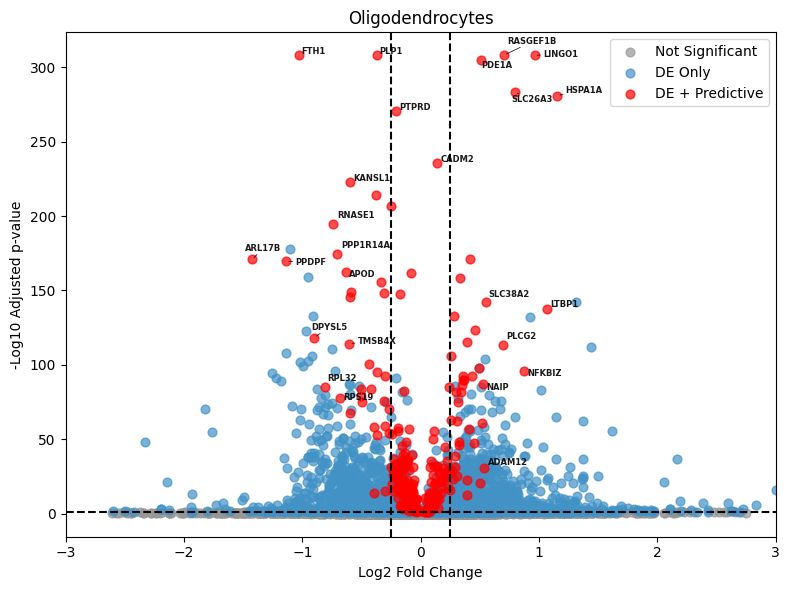

Oligodendrocytes: Volcano plot saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure6/Validation_DE/volcano_Oli_pred_marked.png
Excitatory Neurons: Overlap genes saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Differential_Expression_Final/Overlap_Tables/Validation/overlap_pred_DE_Ex.csv


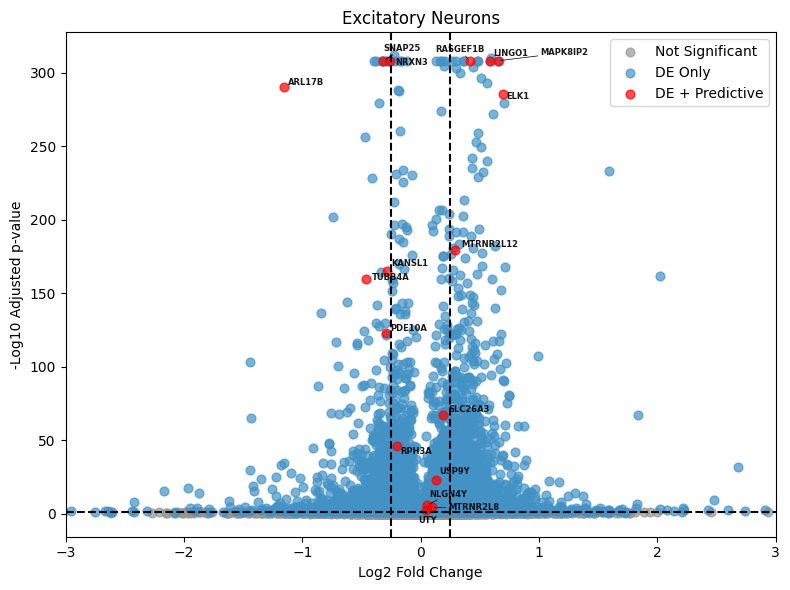

Excitatory Neurons: Volcano plot saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure6/Validation_DE/volcano_Ex_pred_marked.png
Overlap CSVs and volcano plots saved for all cell types!


In [3]:
import os
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from adjustText import adjust_text

# === Paths ===
base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Validation_Multirun_cell_on_cell_genes_Lau_rfe"
de_base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Differential_Expression_Final/Validation/"
out_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Differential_Expression_Final/Overlap_Tables/Validation/"
fig_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure6/Validation_DE/"
os.makedirs(out_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

# === Cell types ===
ct_labels = {
    'Ast': 'Astrocytes',
    'Mic': 'Microglia',
    'In': 'Inhibitory Neurons',
    'Oli': 'Oligodendrocytes',
    'Ex': 'Excitatory Neurons'
}
cell_types = list(ct_labels.keys())

# === DE result files ===
de_files = {
    "Ast": "poisson_DE_results_Ast.csv",
    "Mic": "poisson_DE_results_Mic.csv",
    "In": "poisson_DE_results_In.csv",
    "Oli": "poisson_DE_results_Oli.csv",
    "Ex": "poisson_DE_results_Ex.csv"
}

# === Store predictive genes ===
predictive_genes_dict = {}

# === Process each cell type ===
for cell_type_short in cell_types:
    # --- Build predictive genes using your logic ---
    gene_presence = defaultdict(int)
    for split in range(1, 6):
        joblib_path = os.path.join(base_dir, cell_type_short, f"split_{split}", "maximal_classifier.joblib")
        if not os.path.exists(joblib_path):
            continue
        model = joblib.load(joblib_path)
        feature_names = model.feature_names_in_
        importances = model.feature_importances_
        for gene, imp in zip(feature_names, importances):
            if imp > 0:
                gene_presence[gene.upper()] += 1
    predictive_genes = {gene for gene, count in gene_presence.items() if count >= 2}
    predictive_genes_dict[cell_type_short] = predictive_genes

    # --- Load DE genes ---
    de_path = os.path.join(de_base_dir, de_files[cell_type_short])
    df = pd.read_csv(de_path)
    df = df[df["p_adj"].notnull() & df["log2FC"].notnull()]
    df["gene_upper"] = df["gene"].str.upper()

    # --- Identify DE genes (FDR adjusted p-values) ---
    de_genes = set(df[df["p_adj"] < 0.05]["gene_upper"])

    # --- Find overlap ---
    overlap_genes = predictive_genes & de_genes

    # --- Save overlap CSV ---
    overlap_df = df[df["gene_upper"].isin(overlap_genes)].copy()
    overlap_df = overlap_df[["gene", "p_adj"]].sort_values("p_adj")
    out_path = os.path.join(out_dir, f"overlap_pred_DE_{cell_type_short}.csv")
    overlap_df.to_csv(out_path, index=False)
    print(f"{ct_labels[cell_type_short]}: Overlap genes saved to {out_path}")

    # === Volcano plot ===
    # Replacing very small p values of 0 with a very small value
    df.loc[df["p_adj"] == 0, "p_adj"] = 1e-308
    df["-log10_padj"] = -np.log10(df["p_adj"])
    # Filtering off genes that are more than 20 absolute value log fold away
    df = df[df["log2FC"].abs() <= 20]

    # Thresholds
    logfc_thresh = 0.25
    pval_thresh = 0.05

    # Group assignment
    df["group"] = "Not Significant"
    df.loc[(df["p_adj"] < pval_thresh) & (~df["gene_upper"].isin(predictive_genes)), "group"] = "DE Only"
    df.loc[(df["p_adj"] < pval_thresh) & (df["gene_upper"].isin(predictive_genes)), "group"] = "DE + Predictive"

    # Color map
    color_map = {
    "Not Significant": "#969696",       # medium grey
    "DE Only": "#4292c6",               # medium-deep blue
    "DE + Predictive": "red"         # deep red
    }
    plt.figure(figsize=(8, 6))

    for group, color in color_map.items():
        subset = df[df["group"] == group]
        plt.scatter(subset["log2FC"], subset["-log10_padj"], color=color, alpha=0.7, s=40, label=group)
    df = df[df["log2FC"].between(-3, 3)]

    # xmax = np.ceil(max(abs(df["log2FC"].min()), abs(df["log2FC"].max())) + 0.5)
    # plt.xlim(-xmax, xmax)

    plt.xlim(-3, 3)

    plt.axvline(x=logfc_thresh, color='black', linestyle='--')
    plt.axvline(x=-logfc_thresh, color='black', linestyle='--')
    plt.axhline(y=-np.log10(pval_thresh), color='black', linestyle='--')

    # Label DE + Predictive genes
    label_df = df[df["group"] == "DE + Predictive"]

    top_padj = label_df.nsmallest(10, "p_adj")
    top_up = label_df.nlargest(10, "log2FC")
    top_down = label_df.nsmallest(10, "log2FC")

    final_label_df = pd.concat([top_padj, top_up, top_down]).drop_duplicates(subset="gene_upper")

    texts = []
    for _, row in final_label_df.iterrows():
        texts.append(plt.text(row["log2FC"], row["-log10_padj"], row["gene"], fontsize=6, fontweight="bold", alpha=0.9))

    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

    plt.xlabel("Log2 Fold Change")
    plt.ylabel("-Log10 Adjusted p-value")
    plt.title(f"{ct_labels[cell_type_short]}")
    plt.legend()
    plt.tight_layout()

    fig_path = os.path.join(fig_dir, f"volcano_{cell_type_short}_pred_marked.png")
    plt.savefig(fig_path, dpi=300)
    plt.show()
    print(f"{ct_labels[cell_type_short]}: Volcano plot saved to {fig_path}")

print("Overlap CSVs and volcano plots saved for all cell types!")

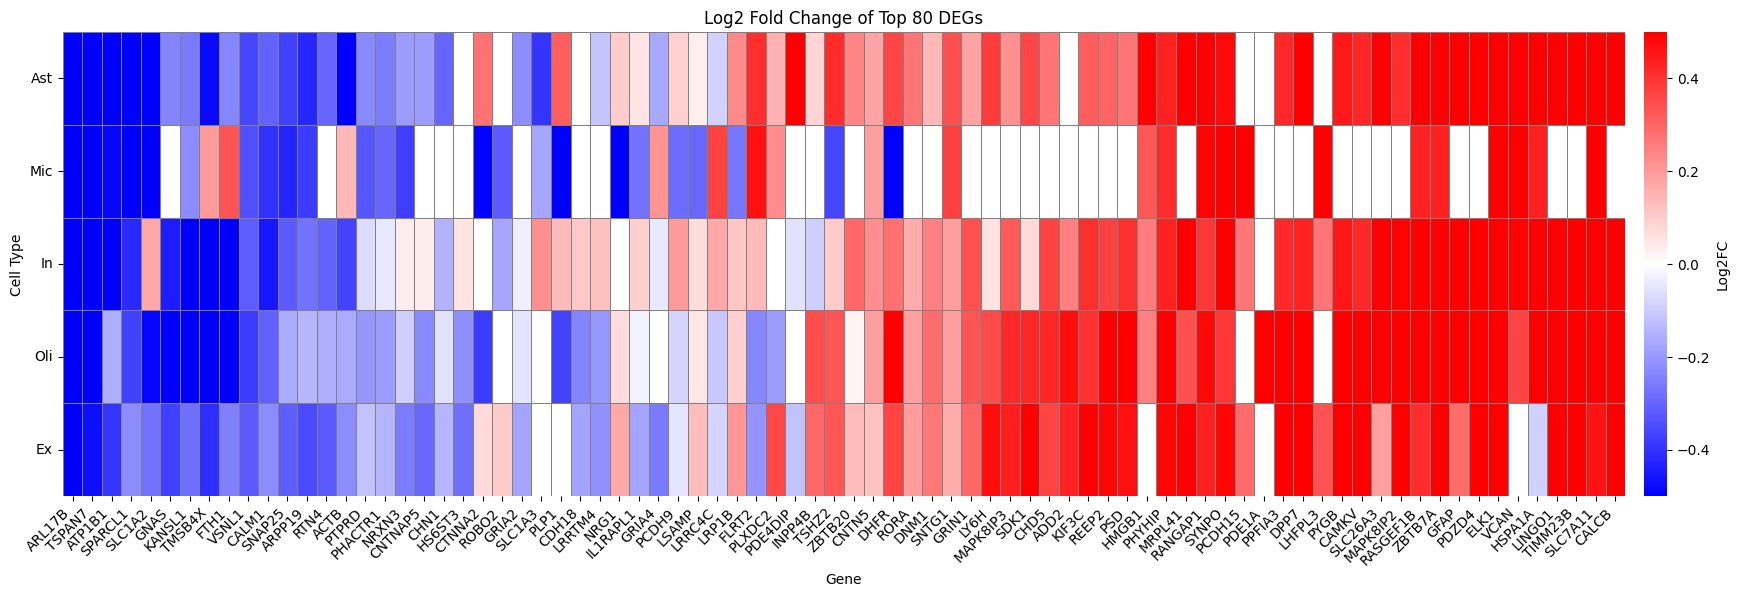

Horizontal heatmap saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure6/heatmap_top50_genes_columns.png


In [5]:
# deg heatmap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# === Paths ===
de_base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Differential_Expression_Final/Validation"
out_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure6/"
os.makedirs(out_dir, exist_ok=True)

# === Cell types ===
cell_types = ["Ast", "Mic", "In", "Oli", "Ex"]
de_files = {
    "Ast": "poisson_DE_results_Ast.csv",
    "Mic": "poisson_DE_results_Mic.csv",
    "In": "poisson_DE_results_In.csv",
    "Oli": "poisson_DE_results_Oli.csv",
    # "Opc": "poisson_DE_results_Opc.csv",
    "Ex": "poisson_DE_results_Ex.csv"
}

# === Collect log2FCs for all genes across cell types ===
gene_log2fc_dict = {}

for ct in cell_types:
    de_path = os.path.join(de_base_dir, de_files[ct])
    df = pd.read_csv(de_path)
    df = df[df["p_adj"] < 0.05]
    for _, row in df.iterrows():
        gene = row["gene"]
        if gene not in gene_log2fc_dict:
            gene_log2fc_dict[gene] = {}
        gene_log2fc_dict[gene][ct] = row["log2FC"]

# === Compute overall significance to select top 50 genes ===
all_dfs = []
for ct in cell_types:
    df = pd.read_csv(os.path.join(de_base_dir, de_files[ct]))
    df = df[df["p_adj"] < 0.05]
    all_dfs.append(df)
combined_df = pd.concat(all_dfs)
# combined_df_grouped = combined_df.groupby("gene")["p_adj"].min().reset_index()
# top_genes = combined_df_grouped.nsmallest(50, "p_adj")["gene"].tolist()
# Group by gene and take minimal p_adj
combined_df_grouped = combined_df.groupby("gene")["p_adj"].min().reset_index()

# Find genes with log2FC > 0.2 in at least one cell type
genes_with_large_fc = combined_df.groupby("gene")["log2FC"].apply(lambda x: np.max(np.abs(x)))
genes_with_large_fc = genes_with_large_fc[genes_with_large_fc > 0.2].index.tolist()

# Keep only those genes in combined_df_grouped
filtered_df = combined_df_grouped[combined_df_grouped["gene"].isin(genes_with_large_fc)]

# Pick top 50 by p_adj from this filtered set
top_genes = filtered_df.nsmallest(80, "p_adj")["gene"].tolist()

# === Build heatmap DataFrame ===
heatmap_df = pd.DataFrame(index=cell_types, columns=top_genes)

for gene in top_genes:
    for ct in cell_types:
        val = gene_log2fc_dict.get(gene, {}).get(ct, np.nan)
        heatmap_df.loc[ct, gene] = val

heatmap_df = heatmap_df.astype(float)

gene_means = heatmap_df.mean(axis=0)
sorted_genes = gene_means.sort_values().index.tolist()
heatmap_df = heatmap_df[sorted_genes]

# === Plot heatmap (genes = columns, cell types = rows) ===
plt.figure(figsize=(24, 8))  # Wide for many genes
sns.heatmap(
    heatmap_df,
    cmap="bwr",
    center=0,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Log2FC', 'pad': 0.01},
    vmin=-0.5, vmax=0.5  # You can adjust after seeing
)
plt.title("Log2 Fold Change of Top 80 DEGs")
plt.xlabel("Gene")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Cell Type")
plt.yticks(rotation=0)
plt.subplots_adjust(bottom=0.3)  # Value between 0 and 1; larger = more space

plt.savefig(os.path.join(out_dir, "validation_heatmap_top80_genes_columns.png"), dpi=300)
plt.show()

print(f"Horizontal heatmap saved to {os.path.join(out_dir, 'heatmap_top50_genes_columns.png')}")